In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from textblob import TextBlob
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [7]:
data = {
    "date": ["2023-01-05","2023-01-18","2023-02-10","2023-02-25"],
    "review": [
        "Battery life is amazing but cost is high",
        "Fast shipping and good product quality",
        "Battery performance is bad and too expensive",
        "Quick delivery but product quality is disappointing"
    ]
}

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,review
0,2023-01-05,Battery life is amazing but cost is high
1,2023-01-18,Fast shipping and good product quality
2,2023-02-10,Battery performance is bad and too expensive
3,2023-02-25,Quick delivery but product quality is disappoi...


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

In [9]:
df['sentiment'] = df['clean_review'].apply(lambda x: TextBlob(x).sentiment.polarity)

df[['review','sentiment']]

,review,sentiment
0,Battery life is amazing but cost is high,0.380000
1,Fast shipping and good product quality,0.450000
2,Battery performance is bad and too expensive,-0.600000
3,Quick delivery but product quality is disappoi...,-0.133333


In [10]:
df['label'] = df['sentiment'].apply(lambda x: 1 if x > 0 else 0)

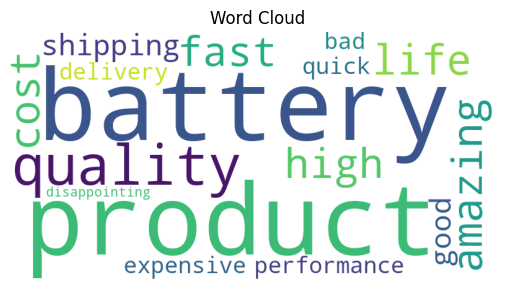

In [11]:
text_data = " ".join(df['clean_review'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [12]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_review'])
y = df['label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\HP\PycharmProjectsAI\NLP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\PycharmProjectsAI\NLP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\PycharmProjectsAI\NLP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.s

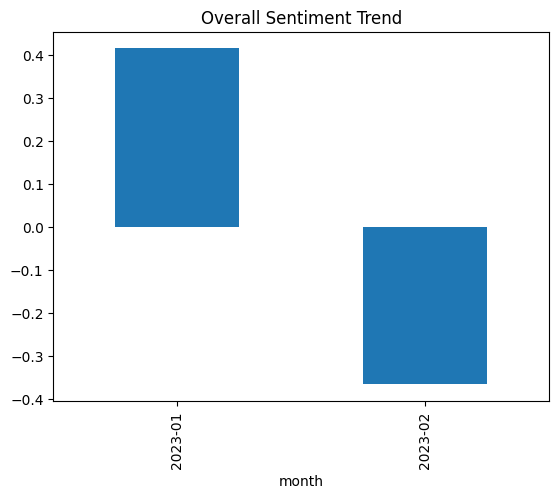

In [16]:
df['month'] = df['date'].dt.to_period('M')

trend = df.groupby('month')['sentiment'].mean()

trend.plot(kind='bar', title="Overall Sentiment Trend")
plt.show()

In [17]:
aspects = {
    "battery": ["battery"],
    "price": ["price", "cost", "expensive"],
    "quality": ["quality", "product"],
    "delivery": ["delivery", "shipping"]
}

aspect_rows = []

for _, row in df.iterrows():
    text = row['clean_review']

    for aspect, keywords in aspects.items():
        if any(word in text for word in keywords):
            aspect_rows.append([row['date'], aspect, text])

aspect_df = pd.DataFrame(aspect_rows, columns=['date','aspect','text'])

aspect_df.head()

,date,aspect,text
0,2023-01-05,battery,battery life is amazing but cost is high
1,2023-01-05,price,battery life is amazing but cost is high
2,2023-01-18,quality,fast shipping and good product quality
3,2023-01-18,delivery,fast shipping and good product quality
4,2023-02-10,battery,battery performance is bad and too expensive


In [18]:
aspect_df['sentiment'] = aspect_df['text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [19]:
aspect_df['month'] = aspect_df['date'].dt.to_period('M')

drift = aspect_df.groupby(['month','aspect'])['sentiment'].mean().unstack()

print(drift)

aspect   battery  delivery  price   quality
month                                      
2023-01     0.38  0.450000   0.38  0.450000
2023-02    -0.60 -0.133333  -0.60 -0.133333


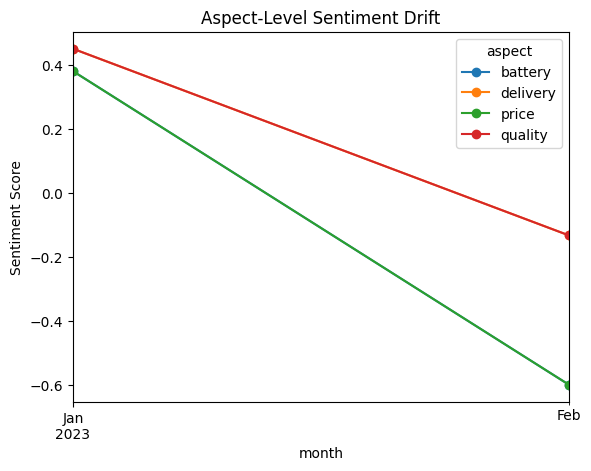

In [20]:
drift.plot(marker='o', title="Aspect-Level Sentiment Drift")
plt.ylabel("Sentiment Score")
plt.show()

In [21]:
positive_text = " ".join(df[df['label']==1]['clean_review'])
negative_text = " ".join(df[df['label']==0]['clean_review'])

WordCloud().generate(positive_text)
WordCloud().generate(negative_text)